# L6 lab 1 · Autopsy of a deep signal

A deep network repeats local transformations. In this lab you will **predict, calculate, run, inspect, and explain** how a small local scale mismatch becomes a depth failure.

We use only NumPy and Matplotlib in deterministic experiments—no downloads and no training loop—so every plot isolates signal and gradient propagation.

## 1. Predict before running

For the scalar chain $h_ℓ=a h_{ℓ-1}$ with $h_0=1$, write down $h_{20}$ for $a ∈ (0.8, 1.0, 1.2)$.

Backprop through the same chain gives $g_0=a^{20}g_{20}$. Which value of $a$ vanishes? Which explodes? Which is preserved?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DEPTH = 20
factors = np.array([0.8, 1.0, 1.2])
values = factors ** DEPTH
for a, value in zip(factors, values):
    print(f"a={a:.1f}:  a^{DEPTH} = {value:.6g}")

assert np.allclose(values, [0.011529215, 1.0, 38.3376], rtol=1e-5)

a=0.8:  a^20 = 0.0115292
a=1.0:  a^20 = 1
a=1.2:  a^20 = 38.3376


**Explain in one sentence:** Why can a 20% local mismatch be severe even though one layer looks harmless?

## 2. Replace the scalar by a small random network

We will track two gauges at each layer:

- forward RMS: $√E[h_ℓ^2]$;
- backward RMS: $√E[g_ℓ^2]$.

Each expectation averages over the batch and units. These are per-coordinate RMS gauges, not total vector norms; labs 2–3 will also use their squared versions. Before running, predict the trace for (a) sigmoid + Xavier and (b) ReLU + He.

In [2]:
rng = np.random.default_rng(6)
BATCH, WIDTH, DEPTH = 384, 96, 20

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40, 40)))

def run_chain(activation, derivative, weight_variance, seed):
    local_rng = np.random.default_rng(seed)
    h = local_rng.standard_normal((BATCH, WIDTH))
    hs, us, weights = [h], [], []
    for _ in range(DEPTH):
        W = local_rng.normal(0, np.sqrt(weight_variance), (WIDTH, WIDTH))
        u = h @ W.T
        h = activation(u)
        weights.append(W); us.append(u); hs.append(h)

    grad = local_rng.standard_normal(h.shape)
    grad_rms = [np.sqrt(np.mean(grad**2))]
    for W, u in zip(weights[::-1], us[::-1]):
        grad = (grad * derivative(u)) @ W
        grad_rms.append(np.sqrt(np.mean(grad**2)))
    grad_rms = np.array(grad_rms[::-1])
    act_rms = np.array([np.sqrt(np.mean(v**2)) for v in hs])
    return act_rms, grad_rms / grad_rms[-1]

sig = run_chain(sigmoid, lambda u: sigmoid(u)*(1-sigmoid(u)), 1/WIDTH, seed=1)
relu = run_chain(lambda u: np.maximum(0, u), lambda u: (u > 0), 2/WIDTH, seed=1)

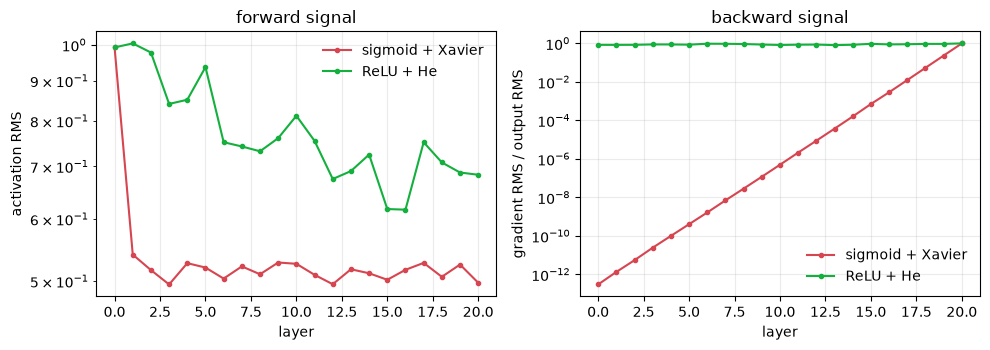

In [3]:
layers = np.arange(DEPTH + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for (name, (act, grad), color) in [
    ("sigmoid + Xavier", sig, "#D64550"),
    ("ReLU + He", relu, "#14B03D"),
]:
    axes[0].semilogy(layers, act, marker=".", label=name, color=color)
    axes[1].semilogy(layers, grad, marker=".", label=name, color=color)
axes[0].set(title="forward signal", xlabel="layer", ylabel="activation RMS")
axes[1].set(title="backward signal", xlabel="layer", ylabel="gradient RMS / output RMS")
for ax in axes:
    ax.grid(alpha=.25); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. Inspect and explain

1. Start at output layer $ℓ=20$ and traverse backward toward input layer $ℓ=0$. At which indexed layer does the sigmoid gradient RMS first fall below $10^{-4}$ of the output RMS?
2. Does ReLU + He preserve every realization exactly, or only keep the scale in a useful range?
3. Why is activation RMS (a second moment) more informative here than variance alone for ReLU outputs?

In [4]:
backward_order = range(DEPTH, -1, -1)
first_small = next(layer for layer in backward_order if sig[1][layer] < 1e-4)
print(f"first crossing below 1e-4 while moving layer {DEPTH} -> 0: layer {first_small}")
print(f"boundary check: layer 14 = {sig[1][14]:.6g}, layer 13 = {sig[1][13]:.6g}")
print("ReLU+He activation RMS range:", relu[0].min().round(3), "to", relu[0].max().round(3))

# grad_rms[layer] is the gauge for g_layer; the output gauge is at index 20.
assert first_small == 13 and sig[1][14] >= 1e-4 > sig[1][13]
assert np.isfinite(relu[0]).all() and np.isfinite(relu[1]).all()

first crossing below 1e-4 while moving layer 20 -> 0: layer 13
boundary check: layer 14 = 0.000159565, layer 13 = 3.71975e-05
ReLU+He activation RMS range: 0.617 to 1.004


### Takeaway

Indexing matters: $g_{20}$ is the output gradient, so the backward search visits $20,19,…,0$ and reports layer 13, where the crossing from layer 14 occurs. Depth turns local multipliers into products; activation derivatives and weight scales therefore have to be designed together and checked layer by layer.